# Test Analysis

In [62]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd

from colors import FLASHForward as FF_cmap

In [47]:
import ocelot

In [53]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\01\DAQ_tests\MultiSourceDAQ_20260401_221029.hdf'

In [54]:
class CLARADataset:

    def __init__(self , filepath , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\1\\' , scope_dir =r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\01\\' ):

        self.filepath = filepath

        self.file = h5py.File(self.filepath , 'r')
        self.image_dir = image_dir
        self.scope_dir = scope_dir

        self.scan_parameters = list(self.file['Settings/Scan Parameters'].keys())

    def load_images_for_step(self , camera , step_no = 0 , ):

        im_file_names = self.file['Dataset']['step_' + f'{step_no}'.zfill(3)][camera][()]
        if im_file_names.decode('utf-8') == 'FAIL':
            return [np.nan]
        
        else:
            im_file = h5py.File(self.image_dir + im_file_names.decode('utf-8') + '_mask.hdf', 'r')
            ims = [im_file[key][()] for key in im_file.keys()]

            return ims
    
    def load_scopes_for_step(self , scope , step_no = 0 , channel = 'Channel1'):
        
        scope_file_names = self.file['Dataset/step_' + f'{step_no}'.zfill(3) + f'/{scope}'][()]
    
        scope_file = h5py.File(self.scope_dir + scope_file_names.decode('utf-8'), 'r')

        scope_data = scope_file[channel]['Segments'][()]

        return list(scope_data)

    def load_data_for_step(self , cameras = [] , scopes = [] , step_no = 0):
        
        data = pd.DataFrame()

        # load images
        for camera in cameras:
            ims = self.load_images_for_step(camera , step_no = step_no)
            data[camera] = ims

        # load scopes
        for scope in scopes:
            scope_data = self.load_scopes_for_step(scope , step_no=step_no)
            data[scope] = scope_data

        step_values = []
        for scan_parameter in self.scan_parameters:
            step_values.append(self.file['Dataset/' + 'step_' + f'{step_no}'.zfill(3) + f'/Scan Parameters/{scan_parameter}'][()])

        if len(self.scan_parameters) != 0:
            data[self.scan_parameters[0]] = step_values[0]

        return data
    
    def load_data(self , cameras = [] , scopes = []):

        datas = []
        for step_no in range(len(self.file['Dataset'].keys())):
            datas.append(self.load_data_for_step(cameras , scopes , step_no))

        datas = pd.concat(datas)
        datas = datas.reset_index(drop=True)
        return datas

In [55]:
dset = CLARADataset(dset_path)

In [56]:
data = dset.load_data(['CLA-FED-DIA-CAM-02'])
data['xprof'] = [im.sum(axis=0) for im in data['CLA-FED-DIA-CAM-02']]
data['yprof'] = [im.sum(axis=1) for im in data['CLA-FED-DIA-CAM-02']]



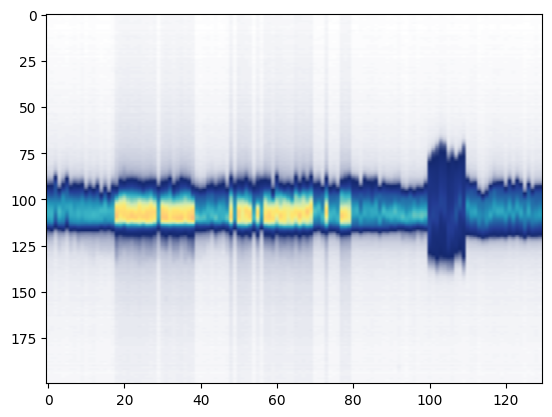

In [64]:
plt.figure()
plt.imshow(np.stack(data.xprof).transpose() , aspect = 'auto' , cmap = FF_cmap)

Text(0.5, 0, 'Shot no (ordered by increasing discharge timing)')

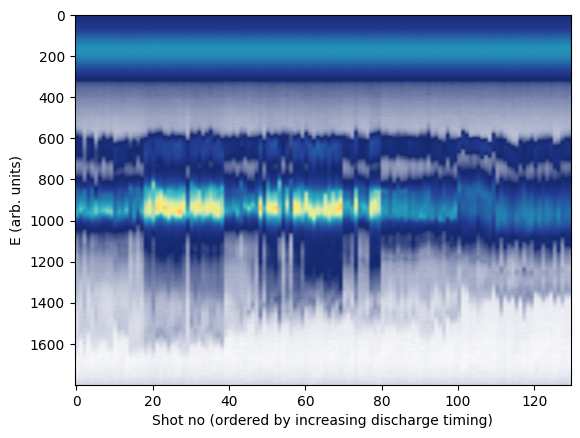

In [65]:
plt.figure()
plt.imshow(np.stack(data.yprof).transpose() , aspect = 'auto' , cmap = FF_cmap)
plt.ylabel('E (arb. units)')
plt.xlabel('Shot no (ordered by increasing discharge timing)')

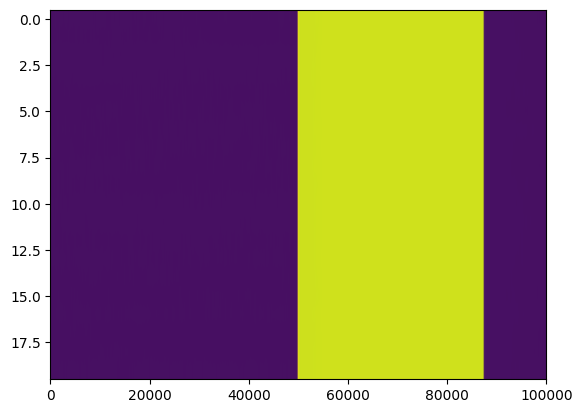

In [104]:
plt.figure()
plt.imshow(np.stack(data['CLA-FEA-DIA-SCOPE-01']) , aspect = 'auto')

In [15]:
data['spec'] = [im.sum(axis = 0) for im in data['CLA-FED-DIA-CAM-02']]

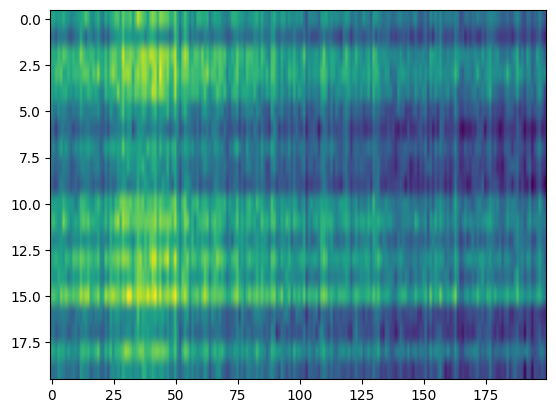

In [16]:
plt.figure()
plt.imshow(np.stack(data.spec) , aspect='auto')

In [57]:
dset.file['Dataset/step_000/CLA-FEA-DIA-SCOPE-01'][()]

b'_20260401_110701.928194_CLA-FEA-DIA-SCOPE-01_data_0.h5'

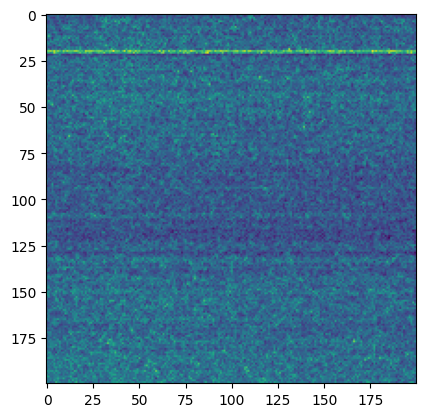

In [116]:
plt.figure()
plt.imshow(ims[0])

In [47]:
im_file_path = r'\\claraserv3.dl.ac.uk\CameraImages\2026\3\31\\'
im_file_names = dset.file['Dataset']['step_000']['CLA-FED-DIA-CAM-02'][()]

im_file = h5py.File(im_file_path + im_file_names.decode('utf-8') + '_mask.hdf', 'r')

In [49]:
im_file['Capture000001'][()].shape

(200, 200)

In [20]:
im_file_names.decode('utf-8') 

'CLA-FED-DIA-CAM-02_2026-03-31_14-19-06UTC_50_images'

In [32]:
f = h5py.File(r'\\claraserv3.dl.ac.uk\CameraImages\2026\3\31\CLA-FED-DIA-CAM-02_2026-03-31_14-19-06UTC_50_images_full.hdf' , 'r')

In [75]:
im_file_names = dset.file['Dataset'].keys()


In [132]:
dset.file['Dataset/step_001/Scan Parameters/ManualScan'][()]

1.25

In [50]:
dset.file['Snapshots/START'].keys()

<KeysViewHDF5 ['CLA-FEA-MAG-QUAD-13', 'CLA-FEA-MAG-QUAD-14', 'CLA-FEA-MAG-QUAD-15']>

In [47]:
dset.file['Snapshots/START']['CLA-FEA-MAG-QUAD-13/CLA-FEA-MAG-QUAD-13'].keys()

<KeysViewHDF5 ['DEGAUSSED', 'LAST_DEGAUSS_SUCCESS', 'READI', 'READK', 'RPOWER', 'SETI', 'SETK', 'SPOWER']>